# Kaggle Titanic - EDA & Modeling

## Contents
1. Import Libraries
2. Load Data
3. EDA
4. Feature Engineering
5. Modeling & Evaluation
6. Generate Submission

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded OK')

Libraries loaded OK


## 2. Load Data

In [2]:
train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')
print(f'train: {train.shape}  /  test: {test.shape}')
train.head()

train: (891, 12)  /  test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. EDA

In [5]:
# Missing values
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)
print(pd.DataFrame({'Missing': missing, 'Pct(%)': missing_pct})[missing > 0])

          Missing  Pct(%)
Cabin         687    77.1
Age           177    19.9
Embarked        2     0.2


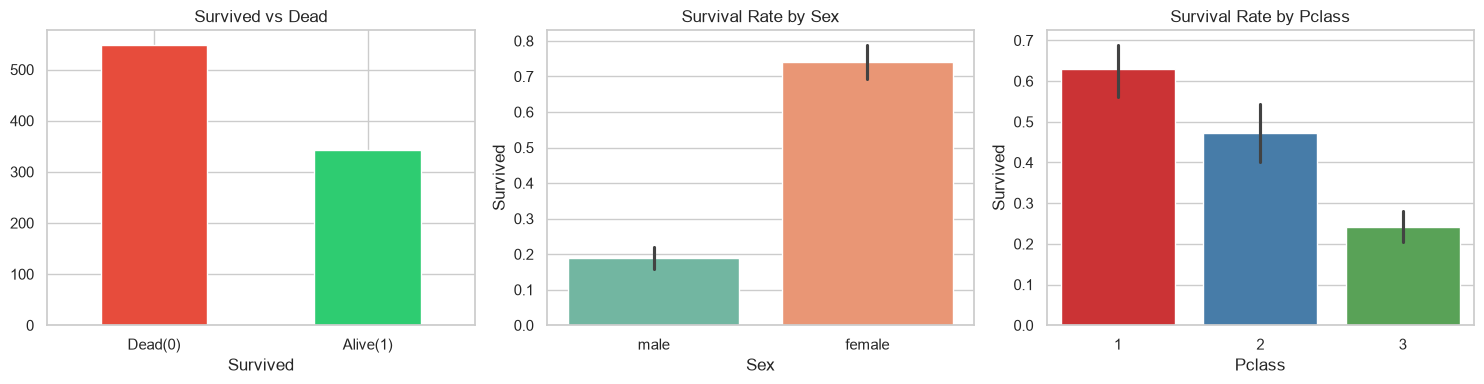

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'])
axes[0].set_title('Survived vs Dead')
axes[0].set_xticklabels(['Dead(0)', 'Alive(1)'], rotation=0)
sns.barplot(data=train, x='Sex', y='Survived', ax=axes[1], palette='Set2')
axes[1].set_title('Survival Rate by Sex')
sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[2], palette='Set1')
axes[2].set_title('Survival Rate by Pclass')
plt.tight_layout()
plt.savefig('../data/processed/survival_overview.png', dpi=150, bbox_inches='tight')
plt.show()

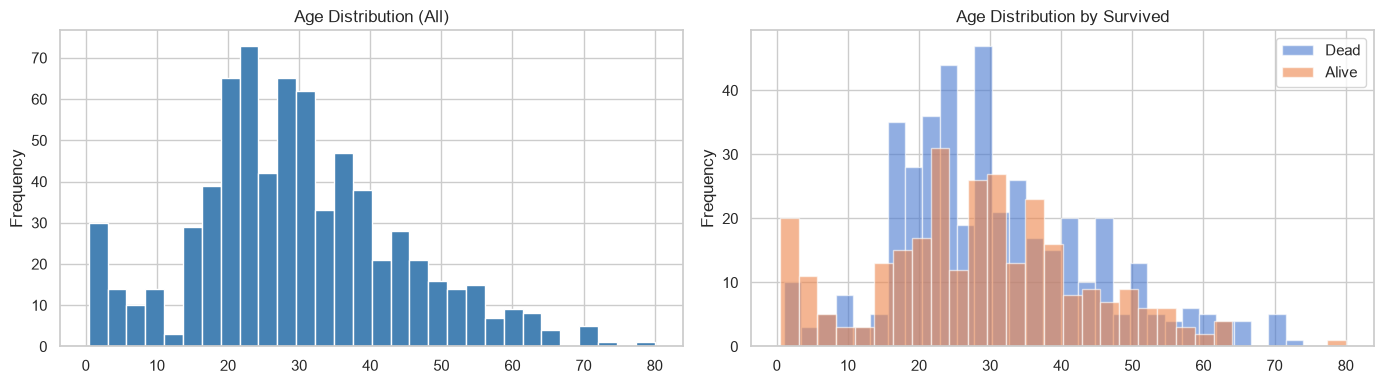

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train['Age'].plot(kind='hist', bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution (All)')
train.groupby('Survived')['Age'].plot(kind='hist', bins=30, alpha=0.6, ax=axes[1])
axes[1].set_title('Age Distribution by Survived')
axes[1].legend(['Dead', 'Alive'])
plt.tight_layout()
plt.savefig('../data/processed/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

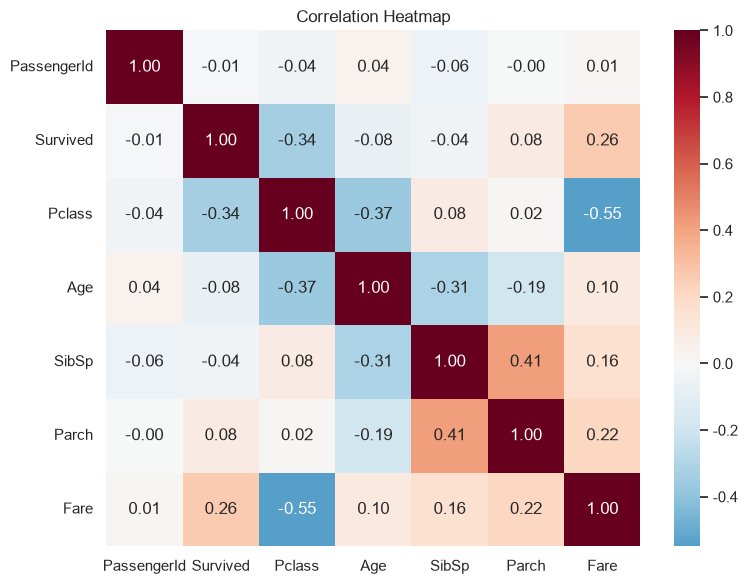

In [8]:
plt.figure(figsize=(8, 6))
numeric_cols = train.select_dtypes(include=[np.number]).columns
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering

In [9]:
# Feature engineering with Group Survival & One-Hot Encoding
df_all = pd.concat([train, test], sort=False).reset_index(drop=True)
df_all['Last_Name'] = df_all['Name'].apply(lambda x: x.split(',')[0])

DEFAULT_SURVIVAL_VALUE = 0.5
df_all['Family_Survival'] = DEFAULT_SURVIVAL_VALUE

# Last_Name & Fare グループ
for grp, grp_df in df_all.groupby(['Last_Name', 'Fare']):
    if len(grp_df) > 1:
        for ind, row in grp_df.iterrows():
            smax = grp_df.drop(ind)['Survived'].max()
            smin = grp_df.drop(ind)['Survived'].min()
            passID = row['PassengerId']
            if smax == 1.0:
                df_all.loc[df_all['PassengerId'] == passID, 'Family_Survival'] = 1.0
            elif smin == 0.0:
                df_all.loc[df_all['PassengerId'] == passID, 'Family_Survival'] = 0.0

# Ticket グループで補完
for grp, grp_df in df_all.groupby('Ticket'):
    if len(grp_df) > 1:
        for ind, row in grp_df.iterrows():
            passID = row['PassengerId']
            if df_all.loc[df_all['PassengerId'] == passID, 'Family_Survival'].values[0] == 0.5:
                smax = grp_df.drop(ind)['Survived'].max()
                smin = grp_df.drop(ind)['Survived'].min()
                if smax == 1.0:
                    df_all.loc[df_all['PassengerId'] == passID, 'Family_Survival'] = 1.0
                elif smin == 0.0:
                    df_all.loc[df_all['PassengerId'] == passID, 'Family_Survival'] = 0.0

# 基本特徴量
df_all['Title'] = df_all['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
title_map = {'Mr':'Mr','Miss':'Miss','Mrs':'Mrs','Master':'Master','Dr':'Rare','Rev':'Rare','Col':'Rare','Major':'Rare','Mlle':'Miss','Countess':'Rare','Ms':'Miss','Lady':'Rare','Jonkheer':'Rare','Don':'Rare','Dona':'Rare','Mme':'Mrs','Capt':'Rare','Sir':'Rare'}
df_all['Title'] = df_all['Title'].map(title_map).fillna('Rare')

# Fare, Embarked, Deck の補完
df_all['Fare'] = df_all['Fare'].fillna(df_all['Fare'].median())
df_all['Embarked'] = df_all['Embarked'].fillna(df_all['Embarked'].mode()[0])
df_all['Deck'] = df_all['Cabin'].fillna('U').apply(lambda x: x[0])
df_all['FamilySize'] = df_all['SibSp'] + df_all['Parch'] + 1
df_all['IsAlone'] = (df_all['FamilySize'] == 1).astype(int)

# --- Age 予測補完 (高度化) ---
from sklearn.ensemble import RandomForestRegressor
age_features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Deck', 'FamilySize', 'IsAlone', 'Age']
df_age_prep = df_all[age_features].copy()
cat_cols_for_age = ['Sex', 'Embarked', 'Title', 'Deck']
df_age_encoded = pd.get_dummies(df_age_prep, columns=cat_cols_for_age, drop_first=True)

train_age = df_age_encoded[df_age_encoded['Age'].notnull()]
test_age = df_age_encoded[df_age_encoded['Age'].isnull()]

X_train_age = train_age.drop(columns=['Age'])
y_train_age = train_age['Age']
X_test_age = test_age.drop(columns=['Age'])

age_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
age_regressor.fit(X_train_age, y_train_age)
predicted_ages = age_regressor.predict(X_test_age)
df_all.loc[df_all['Age'].isnull(), 'Age'] = predicted_ages

# --- 数値特徴量の非線形変換 (Fareの対数変換) とビン化 (パターンC) ---
df_all['Log_Fare'] = np.log1p(df_all['Fare'])
df_all['Age_Bin'] = pd.cut(df_all['Age'], bins=[0, 5, 15, 30, 55, 120], labels=['Infant', 'Child', 'Youth', 'Middle_Aged', 'Senior'])

# One-Hot Encoding (Age_Bin を追加)
cat_cols = ['Sex', 'Embarked', 'Title', 'Deck', 'Age_Bin']
df_encoded = pd.get_dummies(df_all, columns=cat_cols, drop_first=True)

train_fe = df_encoded.iloc[:len(train)].copy()
test_fe = df_encoded.iloc[len(train):].copy()
print('Feature engineering with Group Survival, One-Hot Encoding and Log_Fare/Age_Bin (Pattern C) done')
train_fe.head()


Feature engineering with Group Survival, One-Hot Encoding and Log_Fare/Age_Bin (Pattern C) done


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Last_Name,Family_Survival,FamilySize,IsAlone,Log_Fare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Age_Bin_Child,Age_Bin_Youth,Age_Bin_Middle_Aged,Age_Bin_Senior
0,1,0.0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,Braund,0.5,2,0,2.110213,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,Cumings,0.5,2,0,4.280593,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False
2,3,1.0,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,Heikkinen,0.5,1,1,2.188856,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,Futrelle,0.0,2,0,3.990834,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False
4,5,0.0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,Allen,0.5,1,1,2.202765,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False


In [10]:
# パターンC: 元の Fare と Age を除外して Log_Fare と Age_Bin のみを使用
exclude_cols = ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin', 'Last_Name', 'Fare', 'Age']
features = [col for col in train_fe.columns if col not in exclude_cols]

X_train = train_fe[features]
y_train = train_fe['Survived'].astype(int)
X_test  = test_fe[features]
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


X_train: (891, 26), X_test: (418, 26)


## 5. Modeling & Evaluation

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM':           lgb.LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1, max_depth=3, num_leaves=7, learning_rate=0.05)
}
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f'{name:<25}: {scores.mean():.4f} +/- {scores.std():.4f}')


Logistic Regression      : 0.8474 +/- 0.0096


Random Forest            : 0.8339 +/- 0.0151


XGBoost                  : 0.8283 +/- 0.0196


LightGBM                 : 0.8496 +/- 0.0159


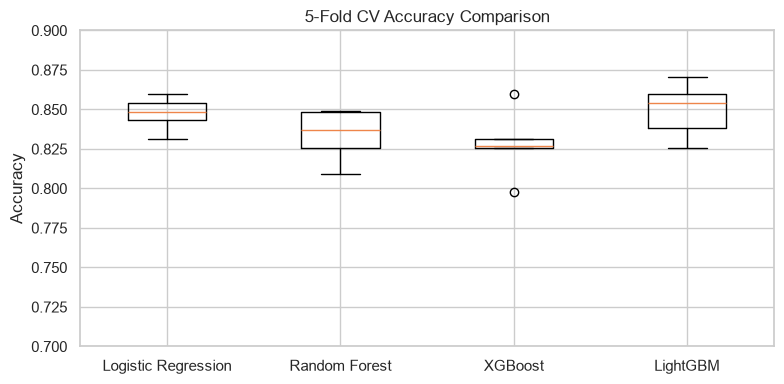

In [12]:
plt.figure(figsize=(8, 4))
plt.boxplot(results.values(), tick_labels=results.keys())
plt.title('5-Fold CV Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.9)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Train LightGBM model which got improved Public Score of 0.79665
best_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1, max_depth=3, num_leaves=7, learning_rate=0.05)
best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions
})
submission.to_csv('../submissions/submission.csv', index=False)
print('Submission file saved to submissions/submission.csv')


Submission file saved to submissions/submission.csv


## 6. Generate Submission

In [14]:
preds = best_model.predict(X_test)
submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': preds})
submission.to_csv('../submissions/submission.csv', index=False)
print('Saved: submissions/submission.csv')
submission.head(10)


Saved: submissions/submission.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
